# Dense Neural Network Baseline

## Importing Libraries

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

## Loading Saved Arrays

In [2]:
X_train = np.load('../data/processed/X_train.npy')
X_val = np.load('../data/processed/X_val.npy')
X_test = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_val = np.load('../data/processed/y_val.npy')
y_test = np.load('../data/processed/y_test.npy')

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(43073, 64, 64, 3) (43073,)
(9230, 64, 64, 3) (9230,)
(9231, 64, 64, 3) (9231,)


## Flattening the Image

In [3]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(X_train_flat.shape, X_val_flat.shape, X_test_flat.shape)

(43073, 12288) (9230, 12288) (9231, 12288)


## Building the Model

- ReLU (Rectified Linear Unit) is a simple nonlinear function: it outputs the input directly if positive, else outputs 0. f(x) = max(0, x)

- activation='softmax' converts the raw output numbers into a probability distribution, that is all 3 outputs will be positive and sum to exactly 1.0

In [4]:
model = keras.Sequential([
    layers.Input(shape=(12288,)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,179,267 (12.13 MB)

 Trainable params: 3,179,267 (12.13 MB)

 Non-trainable params: 0 (0.00 B)

## Compiling the Model

- Adam is an optimization algorithm that decides how the model's weights get updated at each training step, based on the gradients (from backpropagation). 

In [5]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Training the Model

In [6]:
history = model.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=20,
    batch_size=32
)

Epoch 1/20
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 59s 41ms/step - accuracy: 0.5259 - loss: 0.9440 - val_accuracy: 0.5934 - val_loss: 0.8735
Epoch 2/20
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 50s 37ms/step - accuracy: 0.5772 - loss: 0.8701 - val_accuracy: 0.5943 - val_loss: 0.8456
Epoch 3/20
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 82s 37ms/step - accuracy: 0.5937 - loss: 0.8454 - val_accuracy: 0.6161 - val_loss: 0.8417
Epoch 4/20
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 82s 37ms/step - accuracy: 0.6010 - loss: 0.8372 - val_accuracy: 0.6111 - val_loss: 0.8400
Epoch 5/20
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 49s 37ms/step - accuracy: 0.6055 - loss: 0.8248 - val_accuracy: 0.6220 - val_loss: 0.8094
Epoch 6/20
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 50s 37ms/step - accuracy: 0.6108 - loss: 0.8184 - val_accuracy: 0.6264 - val_loss: 0.8032
Epoch 7/20
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 52s 38ms/step - accuracy: 0.6228 - loss: 0.8065 - val_accuracy: 0.6287 - val_loss: 0.7946
Epoch 8/20
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 52s 38ms/step - accuracy: 0.6242 -

## Ploting the Graph


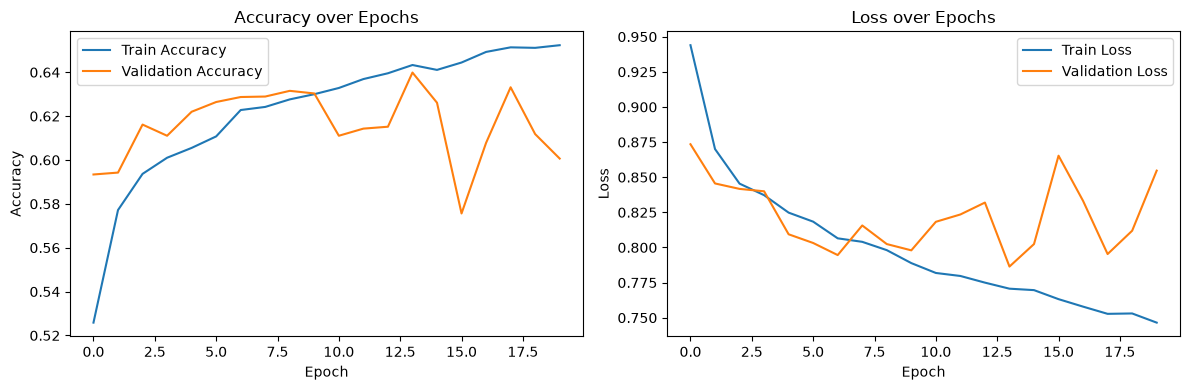

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/baseline_dense_nn_curves.png')
plt.show()

### Observation

Training accuracy keeps going up the whole time (52.6% → 65.2% by epoch 20), but validation accuracy basically stops improving after epoch 9-10 (~63%) and then gets kind of noisy and even drops a bit by the end (~60%). Same thing happens with loss — train loss keeps going down smoothly, but val loss flattens out around epoch 6-9 and then starts going back up.

This is overfitting (high variance) — the model is still learning more about the training set, but that's not translating to better performance on data it hasn't seen. After a certain point it's basically just memorizing quirks in the training images instead of learning patterns that generalize.

Makes sense why this happens here — the first dense layer alone has over 3 million parameters since I flattened each image into 12,288 numbers. That's a lot of capacity for the model to just memorize stuff with, especially compared to dense layers being able to "see" any pattern at all in raw pixels (no spatial structure awareness like a CNN would have).

Also worth noting: my best validation accuracy (~63%) was around epoch 9-10, not at the end. So the model I currently have saved (from the full 20 epochs) is actually a worse version than what I had partway through training. I should add early stopping so training automatically halts near the best point instead of continuing to overfit.

### Retraining with Early Stopping

Based on the overfitting observed above, I'm rebuilding the model from scratch
(to avoid continuing to train an already-overfit model) and adding early
stopping this time, so training halts automatically once validation loss stops
improving.

In [8]:
model = keras.Sequential([
    layers.Input(shape=(12288,)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 52s 37ms/step - accuracy: 0.5466 - loss: 0.9264 - val_accuracy: 0.6093 - val_loss: 0.8384
Epoch 2/20
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 46s 34ms/step - accuracy: 0.5953 - loss: 0.8575 - val_accuracy: 0.6146 - val_loss: 0.8206
Epoch 3/20
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 45s 33ms/step - accuracy: 0.6064 - loss: 0.8345 - val_accuracy: 0.6080 - val_loss: 0.8294
Epoch 4/20
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 45s 33ms/step - accuracy: 0.6092 - loss: 0.8221 - val_accuracy: 0.6085 - val_loss: 0.8586
Epoch 5/20
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 46s 34ms/step - accuracy: 0.6120 - loss: 0.8169 - val_accuracy: 0.6346 - val_loss: 0.8062
Epoch 6/20
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 55s 41ms/step - accuracy: 0.6222 - loss: 0.8023 - val_accuracy: 0.6345 - val_loss: 0.8130
Epoch 7/20
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 55s 41ms/step - accuracy: 0.6248 - loss: 0.7978 - val_accuracy: 0.6340 - val_loss: 0.8030
Epoch 8/20
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 81s 40ms/step - accuracy: 0.6286 -

## Evaluate on Test Set

In [10]:
test_loss, test_accuracy = model.evaluate(X_test_flat, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6346 - loss: 0.7959
Test Loss: 0.7959
Test Accuracy: 0.6346


## Saving the Model

In [11]:
model.save('../models/baseline_dense_nn.keras')